Generating synthetic data for Distance Histogram parity...

          RUNNING REFERENCE FRAMEWORK (SciPy)
-> SciPy reference finished.

          RUNNING DIMREDPY FRAMEWORK
-> DimRedPy calculation finished.

          PARITY VALIDATION
1. MSE on 1D Distance Histogram : 0.000000e+00
2. MSE on 2D Distance Histogram : 0.000000e+00

SUCCESS: DimRedPy Distance Histograms perfectly match SciPy exact reference.
Saved comparison plot to g:\mp\Decoding-Au-clusters\dimredpy_vs_others\dimredpy_vs_analysis\verify_parity_analysis_distance_histogram_plot.png


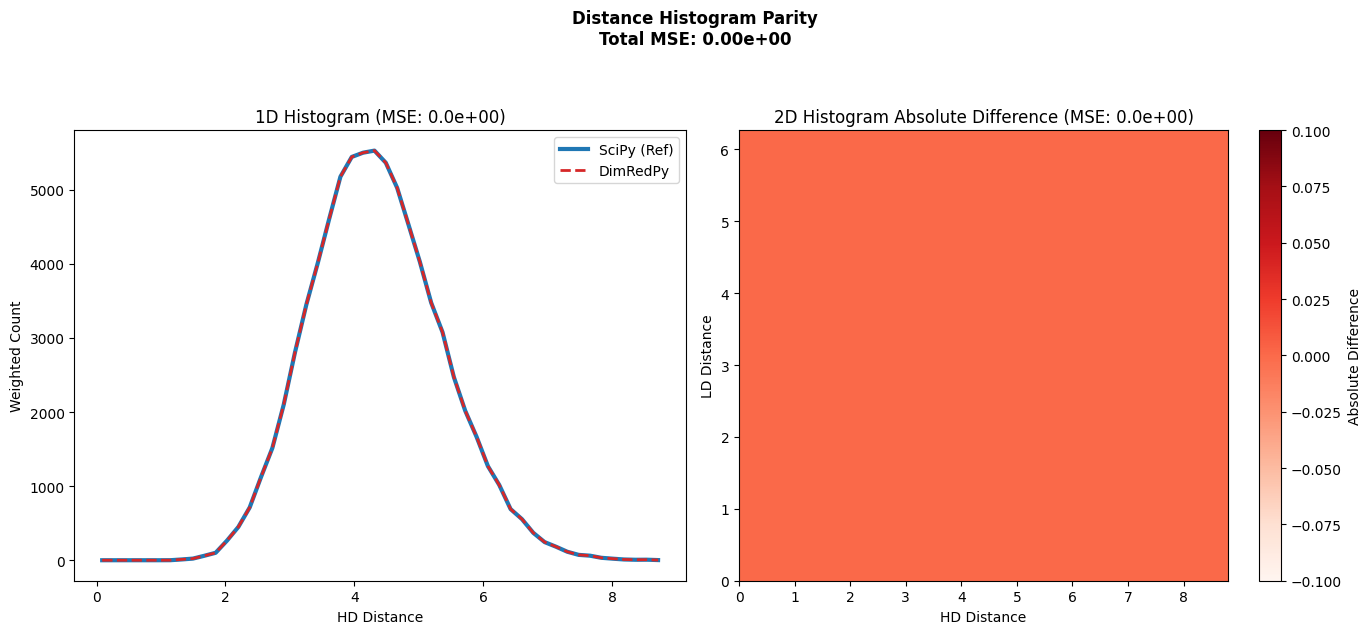

In [1]:
"""
Rigorous Verification of Analysis Parity: Distance Histograms
"""

import numpy as np
import os
import sys
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist

# Robust path detection for repo root
script_dir = os.path.dirname(os.path.abspath(__file__)) if '__file__' in locals() else os.getcwd()
repo_root = os.path.abspath(os.path.join(script_dir, "..", ".."))
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)

from dimredpy.shared.analysis import distance_histogram

# ---------------------------------------------------------------------------
# 1. Generate Synthetic Data
# ---------------------------------------------------------------------------
print("Generating synthetic data for Distance Histogram parity...")
np.random.seed(42)
N = 400
# High-dimensional data (e.g., D=10)
landmarks_hd = np.random.randn(N, 10)
# Low-dimensional data (e.g., d=2)
landmarks_ld = np.random.randn(N, 2)
# Random weights
weights = np.random.uniform(0.5, 1.5, size=N)

n_bins = 50

# ---------------------------------------------------------------------------
# 2. Run Reference Framework (SciPy exact pdist & explicit weights)
# ---------------------------------------------------------------------------
print("\n=======================================================")
print("          RUNNING REFERENCE FRAMEWORK (SciPy)")
print("=======================================================")

# Exact upper-triangle distances using SciPy
ref_hd_dist = pdist(landmarks_hd, metric='euclidean')
ref_ld_dist = pdist(landmarks_ld, metric='euclidean')

# Exact upper-triangle pair weights
# SciPy's pdist flattens the upper triangle in row-major order:
# (0, 1), (0, 2), ..., (0, N-1), (1, 2), ..., (N-2, N-1)
ref_pair_weights = []
for i in range(N):
    for j in range(i + 1, N):
        ref_pair_weights.append(weights[i] * weights[j])
ref_pair_weights = np.array(ref_pair_weights)

# 1D Histogram (HD only)
max_hd = np.max(ref_hd_dist)
edges_hd = np.linspace(0, max_hd, n_bins + 1)
ref_hist1d, _ = np.histogram(ref_hd_dist, bins=edges_hd, weights=ref_pair_weights)

# 2D Histogram (HD vs LD)
max_ld = np.max(ref_ld_dist)
edges_ld = np.linspace(0, max_ld, n_bins + 1)
ref_hist2d, _, _ = np.histogram2d(ref_hd_dist, ref_ld_dist, bins=[edges_hd, edges_ld], weights=ref_pair_weights)

print("-> SciPy reference finished.")

# ---------------------------------------------------------------------------
# 3. Run DimRedPy Framework
# ---------------------------------------------------------------------------
print("\n=======================================================")
print("          RUNNING DIMREDPY FRAMEWORK")
print("=======================================================")

# 1D
res_1d = distance_histogram(landmarks_hd, n_bins=n_bins, weights=weights, max_d=max_hd)
dimred_hist1d = res_1d["histogram_1d"]

# 2D
res_2d = distance_histogram(landmarks_hd, landmarks_ld=landmarks_ld, n_bins=n_bins, weights=weights, max_d=max_hd)
dimred_hist2d = res_2d["histogram_2d"]

print("-> DimRedPy calculation finished.")

# ---------------------------------------------------------------------------
# 4. Parity Validation
# ---------------------------------------------------------------------------
print("\n=======================================================")
print("          PARITY VALIDATION")
print("=======================================================")

mse_1d = np.mean((ref_hist1d - dimred_hist1d) ** 2)
mse_2d = np.mean((ref_hist2d - dimred_hist2d) ** 2)

print(f"1. MSE on 1D Distance Histogram : {mse_1d:.6e}")
print(f"2. MSE on 2D Distance Histogram : {mse_2d:.6e}")

total_mse = mse_1d + mse_2d

if total_mse < 1e-10:
    print("\nSUCCESS: DimRedPy Distance Histograms perfectly match SciPy exact reference.")
else:
    print("\nFAILURE: Statistical divergence detected in distance histogram parity.")

# ---------------------------------------------------------------------------
# 5. Visual Verification
# ---------------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 6), facecolor='white')
fig.suptitle(f"Distance Histogram Parity\nTotal MSE: {total_mse:.2e}", fontweight='bold', y=1.05)

# 1D Plot
x_centers = 0.5 * (edges_hd[:-1] + edges_hd[1:])
axes[0].plot(x_centers, ref_hist1d, label='SciPy (Ref)', linewidth=3, color='#1f77b4')
axes[0].plot(x_centers, dimred_hist1d, label='DimRedPy', linewidth=2, linestyle='--', color='#d62728')
axes[0].set_xlabel("HD Distance")
axes[0].set_ylabel("Weighted Count")
axes[0].set_title(f"1D Histogram (MSE: {mse_1d:.1e})")
axes[0].legend()

# 2D Parity Plot (Difference Heatmap)
diff_2d = np.abs(ref_hist2d - dimred_hist2d)
im = axes[1].imshow(diff_2d.T, origin='lower', aspect='auto', cmap='Reds', 
                    extent=[0, max_hd, 0, max_ld])
axes[1].set_xlabel("HD Distance")
axes[1].set_ylabel("LD Distance")
axes[1].set_title(f"2D Histogram Absolute Difference (MSE: {mse_2d:.1e})")
fig.colorbar(im, ax=axes[1], label="Absolute Difference")

plt.tight_layout()
plot_path = os.path.join(script_dir, "verify_parity_analysis_distance_histogram_plot.png")
plt.savefig(plot_path, dpi=300, bbox_inches='tight')
print(f"Saved comparison plot to {plot_path}")
